# Q1B — Digital Detective: "Missing Boundaries"

**Sobel Edge Detection System**

Humans recognize objects almost instantly, largely because the visual system is
extremely good at locating *edges* — places where intensity changes abruptly and
which correspond to object boundaries. This notebook:

1. Loads `missing_boundaries_input.avif` and converts it to a grayscale signal $I(x,y)$.
2. Reviews the mathematics connecting derivatives/gradients to edge detection.
3. Derives the Sobel kernels and the 2-D convolution operation that applies them.
4. Applies the Sobel filter to reveal the hidden boundaries in the scene.
5. Studies how noise corrupts the gradient image, and how Gaussian smoothing
   helps — and how much smoothing is *too much*.
6. Builds a thresholded edge map and studies the trade-off between suppressing
   noise and preserving weak (faint) edges.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter

plt.rcParams['figure.dpi'] = 110


## 1. Load the image and form the intensity signal I(x,y)

$I(x,y)$ is a finite 2-D discrete signal: a grayscale image of size $M\times N$,
$x=0,\dots,M-1$ (rows), $y=0,\dots,N-1$ (columns), with real-valued intensity at
every pixel. Note: Pillow needs AVIF support (`pillow-avif-plugin` or a recent
Pillow build) to open `.avif` files directly; if it's unavailable on your machine,
convert the file to PNG once and load the PNG instead.

Image size: 675 rows x 1200 columns


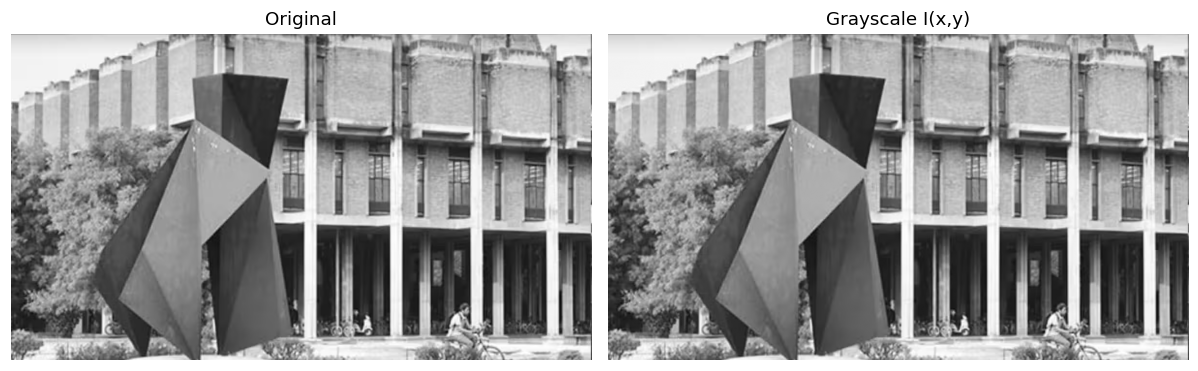

In [ ]:
img_path = "missing_boundaries_input.avif"  

img  = Image.open(img_path).convert("RGB")
gray = np.array(img.convert("L")).astype(np.float64)
M, N = gray.shape
print(f"Image size: {M} rows x {N} columns")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(np.array(img));  ax[0].set_title("Original");        ax[0].axis('off')
ax[1].imshow(gray, cmap='gray'); ax[1].set_title("Grayscale I(x,y)"); ax[1].axis('off')
plt.tight_layout(); plt.show()


## 2. From derivatives to edges

An edge is, by definition, a location where intensity changes rapidly. The
natural mathematical operation that measures "rate of change" is the
**derivative**. For a continuous image $I(x,y)$, the rate of change in each
direction is given by the **gradient**:

$$
\nabla I = \left(\frac{\partial I}{\partial x},\; \frac{\partial I}{\partial y}\right)
= (G_x,\, G_y)
$$

The gradient is a vector at every pixel, pointing in the direction of
steepest intensity increase. Two scalar quantities are derived from it:

$$
\text{Magnitude: } \;|\nabla I| = \sqrt{G_x^2 + G_y^2}
\qquad\qquad
\text{Direction: } \;\theta(x,y) = \arctan\!\left(\frac{G_y}{G_x}\right)
$$

The magnitude is large exactly where intensity changes rapidly in *some*
direction — i.e. at edges — regardless of the edge's orientation. This is the
core mathematical operation behind edge detection: **compute (an
approximation of) the image gradient, then look for large gradient
magnitude.**

For a *discrete* image there is no continuous derivative, so $\partial I/\partial x$
and $\partial I/\partial y$ are approximated by finite differences — which is
exactly what small convolution kernels (like Sobel) compute.

## 3. The Sobel filter and 2-D convolution

The **Sobel operator** approximates $G_x$ and $G_y$ with two small $3\times3$
kernels:

$$
S_x = \begin{bmatrix} -1 & 0 & 1\\ -2 & 0 & 2 \\ -1 & 0 & 1\end{bmatrix}
\qquad\qquad
S_y = \begin{bmatrix} -1 & -2 & -1\\ 0 & 0 & 0 \\ 1 & 2 & 1\end{bmatrix}
$$

$S_x$ responds strongly to vertical edges (horizontal intensity change), and
$S_y$ responds strongly to horizontal edges (vertical intensity change). Each
kernel is, in effect, a smoothed finite-difference: the outer rows/columns
([1,2,1] or [-1,0,1]) act as a small 1-D smoothing pass perpendicular to the
differencing direction, which is why Sobel is noticeably less noise-sensitive
than a plain $[-1,0,1]$ difference.

These kernels are applied with the standard **2-D convolution** operation. For
an image $I$ and a kernel $K$ of size $(2a+1)\times(2b+1)$:

$$
(I * K)(x,y) \;=\; \sum_{s=-a}^{a}\sum_{t=-b}^{b} K(s,t)\, I(x-s,\,y-t)
$$

i.e. flip the kernel, slide it over every pixel, and take the sum of
elementwise products with the underlying neighbourhood. We verify this
definition with our own small implementation before relying on the
much faster library version for the full-size image.

In [3]:
Sx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float64)

Sy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=np.float64)

def my_convolve2d(image, kernel):
    '''A direct, from-scratch implementation of 2-D convolution (zero padding),
    used here only to verify the definition above; the full-size processing
    below uses scipy's optimized convolve2d for speed.'''
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)
    flipped = kernel[::-1, ::-1]               # convolution flips the kernel
    H, W = image.shape
    out = np.zeros_like(image, dtype=np.float64)
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * flipped)
    return out

# Sanity check on a small random patch: hand-written convolution vs. scipy
test_patch = np.random.default_rng(0).random((40, 50))
mine = my_convolve2d(test_patch, Sx)
ref  = convolve2d(test_patch, Sx, mode='same', boundary='fill', fillvalue=0)
print("Max abs difference between manual and scipy convolution:", np.max(np.abs(mine - ref)))


Max abs difference between manual and scipy convolution: 8.881784197001252e-16


## 4. Applying the Sobel filter to the full image

We now convolve the (full-resolution) grayscale image with $S_x$ and $S_y$
using `scipy.signal.convolve2d` (identical result to the manual
implementation above, but fast), then form the gradient magnitude and
direction.

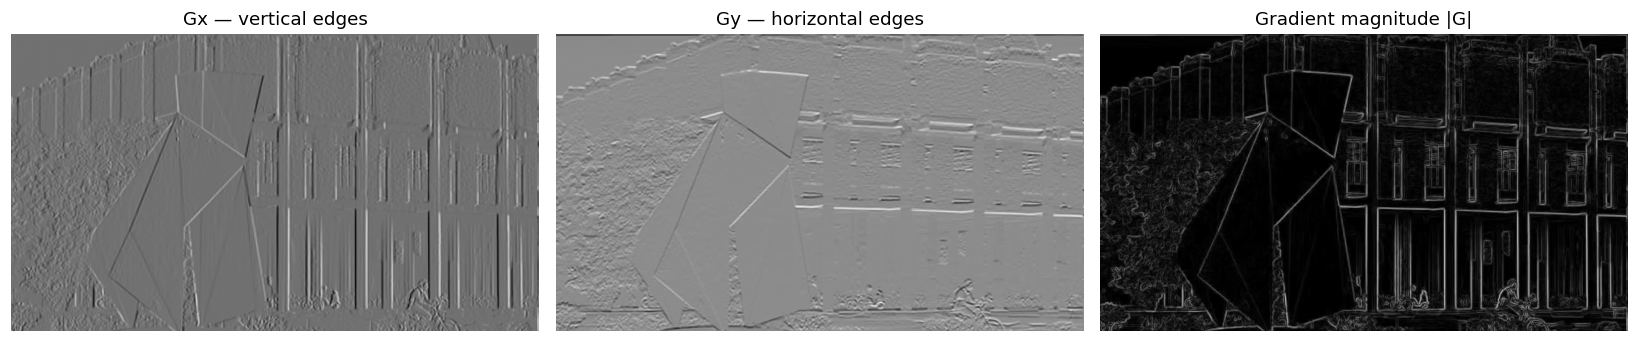

In [4]:
def sobel(image, boundary='symm'):
    gx = convolve2d(image, Sx, mode='same', boundary=boundary)
    gy = convolve2d(image, Sy, mode='same', boundary=boundary)
    mag = np.sqrt(gx**2 + gy**2)
    ang = np.arctan2(gy, gx)
    return gx, gy, mag, ang

Gx, Gy, Mag, Ang = sobel(gray)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
ax[0].imshow(Gx,  cmap='gray'); ax[0].set_title("Gx — vertical edges");   ax[0].axis('off')
ax[1].imshow(Gy,  cmap='gray'); ax[1].set_title("Gy — horizontal edges"); ax[1].axis('off')
ax[2].imshow(Mag, cmap='gray'); ax[2].set_title("Gradient magnitude |G|"); ax[2].axis('off')
plt.tight_layout(); plt.show()


**Observation.** $G_x$ lights up strongly at *vertical* boundaries (window
mullions, building columns, the edges of the sculpture) since it measures
horizontal intensity change, while $G_y$ lights up at *horizontal* boundaries
(window sills, roofline, horizontal beams). The gradient magnitude combines
both and reveals essentially the full outline of every object in the scene —
the "hidden boundaries" the question refers to — directly from the image's
derivative structure, with no manual edge tracing required.

## 5. Effect of noise on the detected boundaries

Because differentiation amplifies high-frequency content, any sensor or
transmission noise (which is broadband / high-frequency) is amplified right
along with the true edges. We simulate this by adding synthetic Gaussian
noise to the image and re-running the same Sobel pipeline, unmodified.

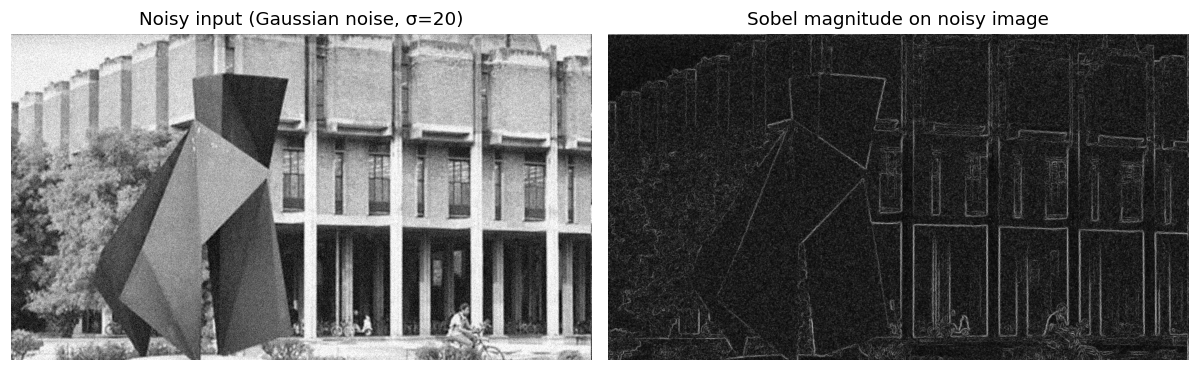

In [5]:
rng = np.random.default_rng(42)
noise_sigma = 20
noisy = np.clip(gray + rng.normal(0, noise_sigma, gray.shape), 0, 255)

_, _, mag_noisy, _ = sobel(noisy)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ax[0].imshow(noisy, cmap='gray');     ax[0].set_title(f"Noisy input (Gaussian noise, σ={noise_sigma})"); ax[0].axis('off')
ax[1].imshow(mag_noisy, cmap='gray'); ax[1].set_title("Sobel magnitude on noisy image");                  ax[1].axis('off')
plt.tight_layout(); plt.show()


**Observation.** The gradient image is now flooded with speckle: every noisy
pixel produces a small, spurious local gradient, and these spurious responses
are comparable in magnitude to many of the genuine but faint edges. This is
the central problem motivating *smoothing before differentiation*.

## 6. Smoothing before edge extraction

Convolution is associative/commutative with itself, so smoothing first with a
Gaussian kernel $G_\sigma$ and then differentiating is equivalent to
convolving with a *derivative-of-Gaussian* kernel — it suppresses
high-frequency noise while still responding to the lower-frequency content of
real edges. We sweep the smoothing strength $\sigma$ and observe the
trade-off directly.

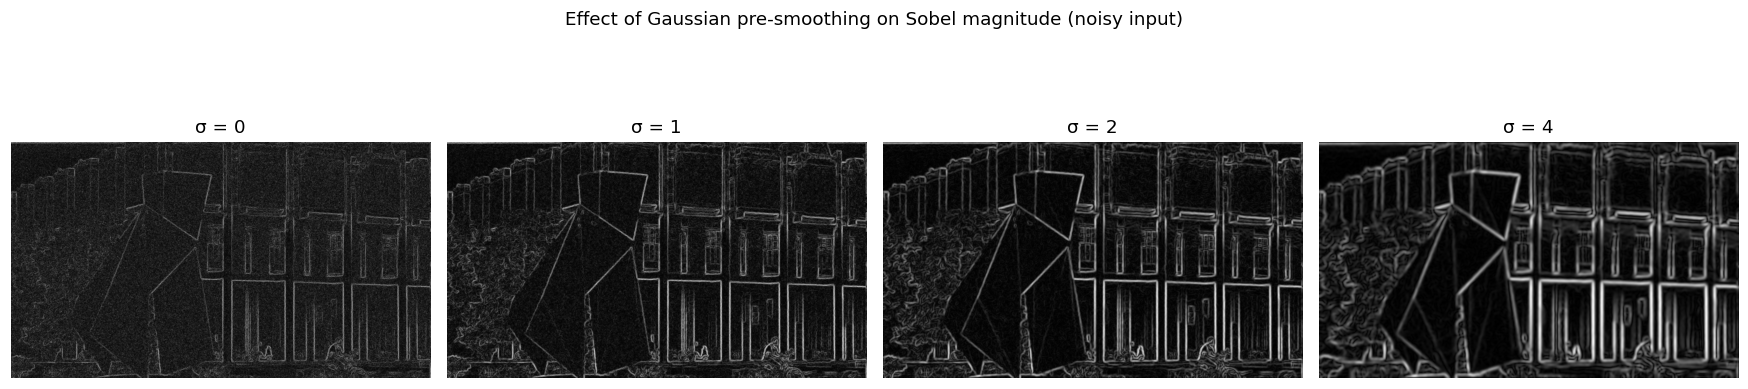

In [6]:
sigmas = [0, 1, 2, 4]
fig, axes = plt.subplots(1, len(sigmas), figsize=(4*len(sigmas), 4.4))
for ax, s in zip(axes, sigmas):
    smoothed = noisy if s == 0 else gaussian_filter(noisy, sigma=s)
    _, _, m, _ = sobel(smoothed)
    ax.imshow(m, cmap='gray'); ax.set_title(f"σ = {s}"); ax.axis('off')
plt.suptitle("Effect of Gaussian pre-smoothing on Sobel magnitude (noisy input)")
plt.tight_layout(); plt.show()


**Observation.** As $\sigma$ increases, the speckle noise is progressively
suppressed and the genuine object boundaries become much cleaner. But
smoothing is itself a low-pass filter: at large $\sigma$ (e.g. $\sigma=4$)
edges become noticeably thicker and closely-spaced fine details (e.g. window
mullions, fine sculpture facets) start to merge or soften. Smoothing
parameter selection is therefore a trade-off, not a "more is always
better" knob — there is a sweet spot between $\sigma\approx1$–$2$ for this
image and noise level.

## 7. Thresholding: turning the gradient map into a binary edge map

The gradient magnitude is continuous-valued; to get a clean boundary map we
threshold it: pixels above $T$ are kept as edges, everything else is
suppressed. We sweep $T$ (expressed as a percentage of the maximum gradient
magnitude) on a mildly smoothed, **clean** version of the image.

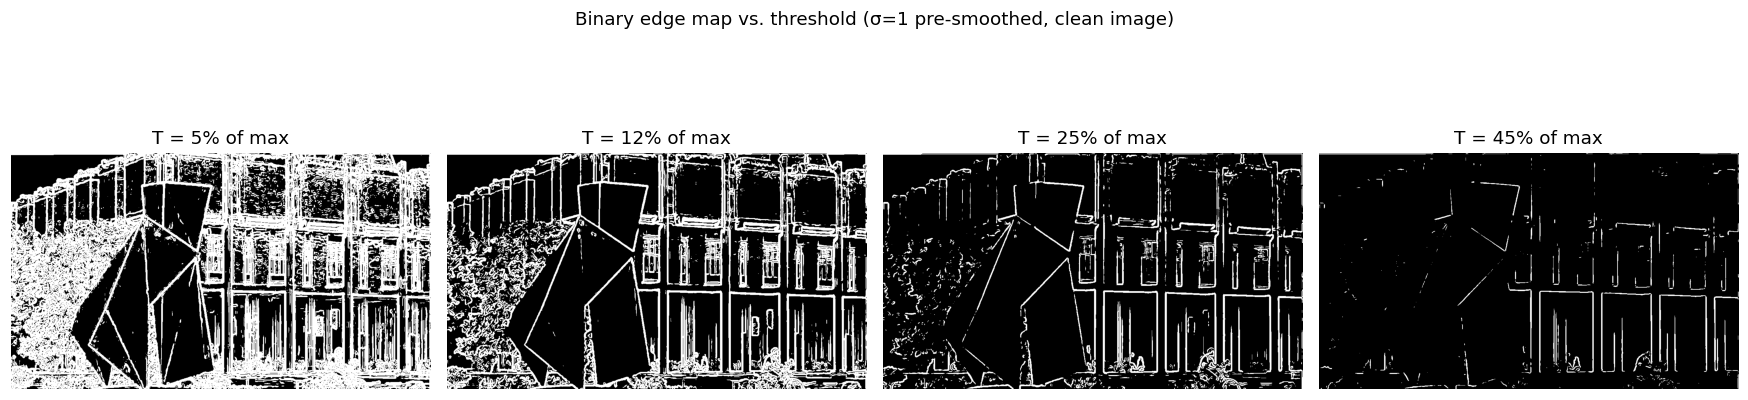

In [7]:
smoothed_clean = gaussian_filter(gray, sigma=1.0)
_, _, mag_work, _ = sobel(smoothed_clean)
mmax = mag_work.max()

thresholds_pct = [0.05, 0.12, 0.25, 0.45]
fig, axes = plt.subplots(1, len(thresholds_pct), figsize=(4*len(thresholds_pct), 4.6))
for ax, tp in zip(axes, thresholds_pct):
    edge_map = (mag_work > tp*mmax).astype(np.uint8) * 255
    ax.imshow(edge_map, cmap='gray'); ax.set_title(f"T = {tp*100:.0f}% of max"); ax.axis('off')
plt.suptitle("Binary edge map vs. threshold (σ=1 pre-smoothed, clean image)")
plt.tight_layout(); plt.show()


**Observation.** A very low threshold keeps almost every pixel with any
gradient at all — including faint texture in the foliage that is not really a
meaningful "boundary." A very high threshold keeps only the strongest, most
unambiguous edges (the sculpture's silhouette, the main building lines) but
starts to drop weaker-but-real edges, such as faint window divisions. The
useful operating point lies in between.

## 8. Can weak edges be preserved without excessive noise?

We now combine the two knobs — smoothing $\sigma$ and threshold $T$ — and
compare three operating points on the **noisy** image to directly answer the
question: *can faint, real edges be kept while noise is suppressed?*

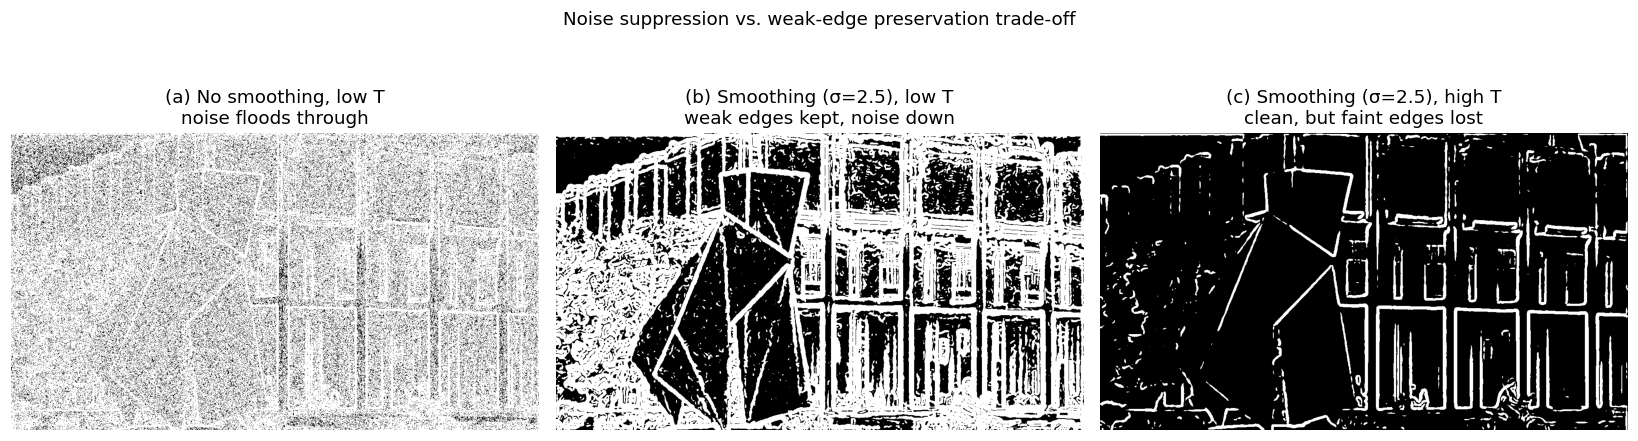

In [8]:
# (a) No smoothing, low threshold  -> noise floods through
_, _, mag_a, _ = sobel(noisy)
edge_a = (mag_a > 0.06*mag_a.max()).astype(np.uint8) * 255

# (b) Smoothing (sigma=2.5), low threshold -> weak edges largely kept, most noise suppressed
sm = gaussian_filter(noisy, sigma=2.5)
_, _, mag_b, _ = sobel(sm)
edge_b = (mag_b > 0.06*mag_b.max()).astype(np.uint8) * 255

# (c) Smoothing (sigma=2.5), high threshold -> very clean, but faint edges are lost
edge_c = (mag_b > 0.30*mag_b.max()).astype(np.uint8) * 255

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
ax[0].imshow(edge_a, cmap='gray'); ax[0].set_title("(a) No smoothing, low T\nnoise floods through");              ax[0].axis('off')
ax[1].imshow(edge_b, cmap='gray'); ax[1].set_title("(b) Smoothing (σ=2.5), low T\nweak edges kept, noise down");   ax[1].axis('off')
ax[2].imshow(edge_c, cmap='gray'); ax[2].set_title("(c) Smoothing (σ=2.5), high T\nclean, but faint edges lost");  ax[2].axis('off')
plt.suptitle("Noise suppression vs. weak-edge preservation trade-off")
plt.tight_layout(); plt.show()


**Answer.** Yes — weak edges *can* be preserved without excessive noise, but
only over a limited range: moderate smoothing (σ≈2–3) removes most of the
random pixel-level noise while leaving genuine low-contrast edges intact
(panel b), because real edges are spatially coherent across many pixels while
noise is not — smoothing exploits exactly that difference. However, this is
not a perfect trade: textured regions (here, the tree foliage) generate dense
local gradients that look statistically similar to noise, so some
"noise-like" response in textured areas is very hard to fully eliminate with
a simple Sobel + Gaussian + single threshold pipeline. Pushing the threshold
higher to clean up texture (panel c) inevitably also removes real but faint
edges. Beyond this point, more advanced techniques (e.g. non-maximum
suppression and hysteresis thresholding, as used in the Canny detector) are
needed to do better than a single global threshold can.

## 9. Final recommended pipeline and full comparison

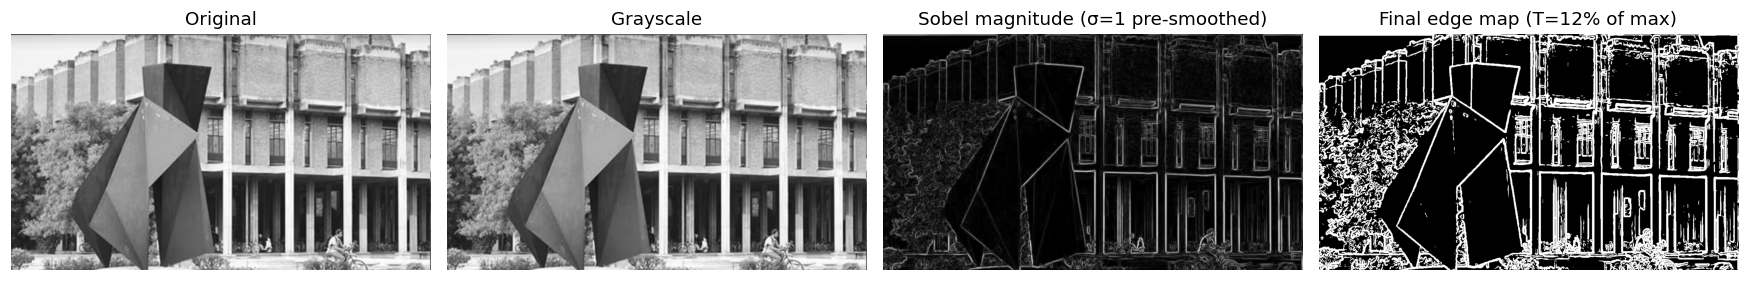

In [9]:
# Final pipeline: mild Gaussian smoothing (sigma=1) + moderate threshold (12% of max)
T_final = 0.12
edge_final = (mag_work > T_final*mmax).astype(np.uint8) * 255

fig, ax = plt.subplots(1, 4, figsize=(16, 4.6))
ax[0].imshow(np.array(img));         ax[0].set_title("Original");                          ax[0].axis('off')
ax[1].imshow(gray, cmap='gray');     ax[1].set_title("Grayscale");                          ax[1].axis('off')
ax[2].imshow(mag_work, cmap='gray'); ax[2].set_title("Sobel magnitude (σ=1 pre-smoothed)");  ax[2].axis('off')
ax[3].imshow(edge_final, cmap='gray'); ax[3].set_title(f"Final edge map (T={T_final*100:.0f}% of max)"); ax[3].axis('off')
plt.tight_layout(); plt.show()


## 10. Conclusion

- Edge detection is fundamentally a derivative/gradient-finding operation:
  edges are pixels where the gradient magnitude $|\nabla I|=\sqrt{G_x^2+G_y^2}$
  is large.
- The Sobel filter approximates $G_x,G_y$ with two small, built-in-smoothed
  $3\times3$ kernels applied via standard 2-D convolution.
- Because differentiation amplifies high-frequency content, noise is
  amplified right along with true edges — this was directly visible once
  synthetic noise was added.
- Gaussian smoothing *before* the Sobel filter substantially suppresses noise
  while preserving genuine edges, but oversmoothing thickens/merges edges and
  destroys fine detail — there is a sweet-spot $\sigma$, not a "more is
  better" relationship.
- Thresholding the gradient magnitude converts it into a binary boundary map;
  the threshold trades off retaining weak/faint edges against suppressing
  residual noise and texture, and a single global threshold cannot fully
  separate the two — this is exactly the limitation that more advanced edge
  detectors (e.g. Canny, with non-maximum suppression + hysteresis) are
  designed to address.
